# Tractable Buffer Stock Model

HARK's primary focus is on heterogeneous agents models that are plausibly related to the real world, and can be used to investigate and understand empirical observations. However, it also includes a relatively simple model that is intended only for teaching and learning about the mechanisms underlying consumption-saving models, the `TractableConsumerType` based on Chris Carroll's "tractable buffer stock model" (see extensive lecture notes [here](https://llorracc.github.io/TractableBufferStock/)).

In [1]:
# Import needed tools
from time import time  # timing utility
import numpy as np  # numeric Python
import matplotlib.pyplot as plt

from HARK.models import MarkovConsumerType, TractableConsumerType
from HARK.distributions import DiscreteDistributionLabeled
from HARK.utilities import plot_funcs  # basic plotting tools

mystr = lambda x: "{:.4f}".format(x)

## Statement of Tractable Buffer Stock Model

While most models in HARK are designed to be compatible with both infinite horizon and life-cycle specification, the tractable buffer stock model is *only* an infinite horizon model. The key feature that makes it somewhat "tractable" is that the nature of risk is *very* specific. The agent begins employed, and their income grows at a constant rate while they remain employed. The only risk is a constant probability that they will become unemployed and *never* receive labor income again.

An agent who will never again receive non-capital income is faced with a "cake-eating problem"; with CRRA preferences, the optimal solution is to consume a constant fraction of remaining wealth (with a simple closed form MPC). The crux of the problem is to find optimal consumption when still employed. The fact that there are only *two* possible future state realizations greatly aids in characterizing optimal behavior under risk.

$\newcommand{\UnempPrb}{\mho}$
$\newcommand{\CRRA}{\rho}$
$\newcommand{\DiscFac}{\beta}$
$\newcommand{\PermGroFac}{\Gamma}$
$\newcommand{\PermGroFacBase}{G}$
$\newcommand{\Rfree}{\mathsf{R}}$
$\newcommand{\Reff}{\mathcal{R}}$
$\newcommand{\PFMPC}{\overline{\kappa}}$

While still employed, the (income-normalized) model can be written in Bellman form as:

\begin{align*}
\text{v}_e({m}_t) &= \max_{{c}_t \leq m_t} ~ \frac{c_t^{1-\CRRA}}{1-\CRRA} + \DiscFac \left( \overbrace{\UnempPrb \text{v}_{u}(m_{t+1})}^{\text{unemployed}} + \overbrace{(1-\UnempPrb) \PermGroFac^{1-\CRRA} \text{v}_{e}(m_{t+1})}^{\text{employed}} \right) \\
& \text{s.t.}  \\
{m}_{t+1} &= \begin{cases}
\Rfree(m_{t}-c_{t})/\PermGroFac + 1 & \text{if employed} \\
\Rfree(m_{t}-c_{t}) & \text{if unemployed} \\
\end{cases}.
\end{align*}

Once unemployed, the model is simply:

\begin{align*}
\text{v}_u({m}_t) &= \max_{{c}_t \leq m_t} ~ \frac{c_t^{1-\CRRA}}{1-\CRRA} + \DiscFac \text{v}_{u}(m_{t+1})\\
& \text{s.t.}  \\
{m}_{t+1} &= \Rfree (m_{t}-c_{t}).
\end{align*}

The permanent income growth factor $\PermGroFac$ is *risk-compensated* from a base value of $\PermGroFacBase$, so that $\PermGroFac = \PermGroFacBase / (1 - \UnempPrb)$. This parameterization lets us separate the *riskiness* of a higher unemployment rate from a change in human wealth (from fewer expected future periods with labor income).

## Solving the Tractable Buffer Stock Model

Most consumption-saving models in HARK are solved using the endogenous grid method (EGM), but the tractable buffer stock model permits a different solution method that Chris Carroll calls "backshooting". Please see his careful lecture notes for a full treatment.

First, he shows that a unique "target" market-resources-to-income ratio exists, conditional on parameter restrictions. The target $\hat{m}$ represents the market resources ratio at which $m_{t+1} = m_t$ as long as the agent remains employed; above $\hat{m}$, they will spend down toward it, and below $\hat{m}$ they will save up to it. Importantly, Chris shows that $\hat{m}$ can be found in closed form.

Next, he characterizes the (employed) consumption function at $\hat{m}$ in terms of its level $\hat{c}$ and first three derivatives: the marginal propensity to consumpe (MPC), the marginal marginal propensity to consume (MMPC), and the marginal marginal marginal propensity to consume (MMMPC). Trivially, we also know that $c_t = 0$ if $m_t = 0$, and Chris derives the limit of the MPC as $m_t \rightarrow 0$.

The level and derivatives of the consumption function at $\hat{m}$ generate a Taylor approximation to the employed consumption function that is *very* accurate nearby to $\hat{m}$. The Taylor approximation is used to generate a few more points on the consumption function slightly above and below $\hat{m}$, perturbing by some fairly small $\epsilon$.

The idea of backshooting is that if we know some point on the employed consumption function $(m_t, c_t)$, and we also know the unemployed consumption function in closed form (i.e. consume linearly at the perfect foresight marginal propensity to consume $\PFMPC$), then we can deduce what the *prior* employed consumption value $c_{t-1}$ must have been if the agent acted optimally; reversing the model's dynamics recovers the $m_{t-1}$ from which it was chosen.

Specifically, the first order condition when employed says:

\begin{align*}
c_t^{-\CRRA} - \DiscFac \Rfree \left( \UnempPrb \text{v}'_u(\Rfree(m_t - c_t)) + (1-\UnempPrb) \PermGroFac^{-\CRRA} \text{v}'_e(\Rfree(m_t - c_t)/\PermGroFac + 1) \right) = 0 \\
\Longrightarrow c_t^{-\CRRA} = \DiscFac \Rfree \left( \UnempPrb \text{v}'_u(\Rfree(m_t - c_t)) + (1-\UnempPrb) \PermGroFac^{-\CRRA} \text{v}'_e(\Rfree(m_t - c_t)/\PermGroFac + 1) \right).
\end{align*}

When backshooting, we know $m_{t+1}^e = \Rfree(m_t - c_t)/\PermGroFac + 1$ and the associated $c_{t+1}^e$, as previously discovered point on the employed consumption function. From these values, it is easy to calculate what market resources *would have been* had we become unemployed this period instead, $m_{t+1}^u$. Because the unemployed consumption function is linear, we can also calculate what our consumption *would have been* had we become unemployed, $c_{t+1}^u$.

The envelope condition says that marginal value of market resources equals the marginal utility of consumption at that $m_t$, whether employed or unemployed. Substituting the envelope condition into the first order condition yields:

\begin{align*}
c_t^{-\CRRA} &= \DiscFac \Rfree \left( \UnempPrb (c_{t+1}^u)^{-\CRRA} + (1-\UnempPrb) (\PermGroFac c_{t+1}^e)^{-\CRRA} \right) \\
\Longrightarrow c_t &= \left( \DiscFac \Rfree \left( \UnempPrb (c_{t+1}^u)^{-\CRRA} + (1-\UnempPrb) (\PermGroFac c_{t+1}^e)^{-\CRRA} \right) \right)^{-1/\CRRA}.
\end{align*}

We can thus recover what employed consumption *must have been* last period if the agent acted optimally and ended that period with $a_t = m_t - c_t$ in retained assets. That asset level is easily known given that we started with a $m_{t+1}^e$ value, so we can invert the dynamics to recover $m_t$ as well. Thus we have "shot backward" in time along the consumption function, finding a new point that can in turn be used to shoot back further.

In HARK's solver, this process starts from several points slightly above and below target market resources $\hat{m}$. For each initial point on the consumption function, the backshooting iteration stops when the implied $m_t$ goes below zero or above some high limit. The overall employed consumption function is constructed as a linear interpolation of all discovered points, as well as the lower bound at $(m,c) = (0,0)$.

## Example Parameter Values for `TractableConsumerType`

Because of its simplicity, there are many fewer parameters to specify a `TractableConsumerType` relative to other HARK models. Note that you must leave the default `cycles=0`, or the model might do unexpected things.

| Parameter | Description | Code | Value |
| :---: | --- | --- | --- |
| $\DiscFac$ |Intertemporal discount factor  | `DiscFac` | $0.975$ |
| $\CRRA$|Coefficient of relative risk aversion | `CRRA` | $1.0$ |
| $\Rfree$ | Risk free interest factor | `Rfree` | $1.01$ |
| $\PermGroFacBase$| Uncompensated permanent income growth factor | `PermGroFac` | $1.0025$ |
| $\UnempPrb$ | Probability of becoming permanently unemployed | `UnempPrb` | $0.00625$ |

## Example Implementation of `TractableConsumerType`

The default parameters can be used right off the shelf to solve an example model, so let's do that.

In [2]:
# Make and solve a tractable consumer type
ExampleType = TractableConsumerType()
t0 = time()
ExampleType.solve()
t1 = time()
print(
    "Solving a tractable consumption-savings model took " + mystr(t1 - t0) + " seconds."
)

Solving a tractable consumption-savings model took 0.0033 seconds.


That was fast! Indeed, the tractable buffer stock model is very specialized, so the infinite horizon solution can be found in hardly any time at all. Let's plot the consumption function when (un)employed.

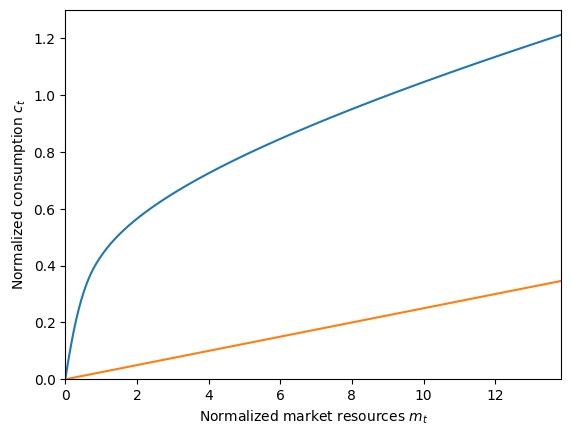

In [3]:
# Plot the consumption function
m_upper = 1.5 * ExampleType.mTarg
plt.ylim(0.0, 1.3)
plt.xlabel("Normalized market resources $m_t$")
plt.ylabel(r"Normalized consumption $c_t$")
plot_funcs([ExampleType.solution[0].cFunc, ExampleType.solution[0].cFunc_U], 0, m_upper)

The concave blue curve represents the consumption function when employed, and the linear orange plot is the consumption function when unemployed.

## Doing it the Long Way

One way to verify this incredibly fast solution method is to compare it to the solution produced when solving by backward induction. We can use the `MarkovConsumerType` to represent agents with two discrete states, employed and unemployed. We'll have to overwrite the default income process in order to make the unemployed state have zero income.

We'll make a parameter dictionary that reproduces the tractable buffer stock model using `MarkovConsumerType`.

In [4]:
# Make a parameter dictionary for the Markov model
my_params = {
    "CRRA": 1.0,  # Coefficient of relative risk aversion
    "Mrkv_p11": [1.0 - ExampleType.UnempPrb],  # Probability of remaining employed
    "Mrkv_p22": [1.0],  # Probability of remaining unemployed
    "DiscFac": ExampleType.DiscFac,  # Intertemporal discount factor
    "PermGroFac": [np.array([ExampleType.PermGroFacCmp, ExampleType.PermGroFacCmp])],
    "Rfree": [np.array([ExampleType.Rfree, ExampleType.Rfree])],  # Constant interest
    "LivPrb": [np.array([1.0, 1.0])],  # No mortality in this model
    "BoroCnstArt": None,  # Artificial borrowing constraint
    "PermShkStd": np.array([[0.0, 0.0]]),  # Permanent shock standard deviation
    "PermShkCount": 1,  # Number of shocks in discrete permanent shock distribution
    "TranShkStd": np.array([[0.0, 0.0]]),  # Transitory shock standard deviation
    "TranShkCount": 1,  # Number of shocks in discrete permanent shock distribution
    "CubicBool": True,  # Use cubic spline interpolation
    "T_cycle": 1,  # Number of periods in cycle
    "cycles": 0,  # Infinite horizon
    "constructors": {"IncShkDstn": None, "PermShkDstn": None, "TranShkDstn": None},
    "tolerance": 1e-8,  # Be very discerning about convergence
}
MarkovType = MarkovConsumerType(**my_params)  # Make a Markov consumer type

Because we canceled the construction of `IncShkDstn` (etc), we need to manually fill in that attribute. In this case, it's a list with two elements: a trivial employed distribution and a trivial unemployed distribution.

In [5]:
# Manually override the income shock process

# Income distribution when employed
employed_income_dist = DiscreteDistributionLabeled(
    pmv=np.ones(1),
    atoms=np.array([[1.0], [1.0]]),
    var_names=["PermShk", "TranShk"],
)

# Income distribution when permanently unemployed
unemployed_income_dist = DiscreteDistributionLabeled(
    pmv=np.ones(1),
    atoms=np.array([[1.0], [0.0]]),
    var_names=["PermShk", "TranShk"],
)

# Set the income distribution in each state
MarkovType.IncShkDstn = [[employed_income_dist, unemployed_income_dist]]

Now we can solve our `MarkovConsumerType`:

In [6]:
# Solve the "Markov TBS" model
t0 = time()
MarkovType.solve()
t1 = time()
MarkovType.unpack("cFunc")
print('Solving the same model "the long way" took ' + mystr(t1 - t0) + " seconds.")

Solving the same model "the long way" took 0.8793 seconds.


It's still quick in absolute terms, but it takes hundreds of times longer to solve the same model using `MarkovConsumerType` than with the specialized solver for the tractable buffer stock model. Did we get the same solution? Let's find out!

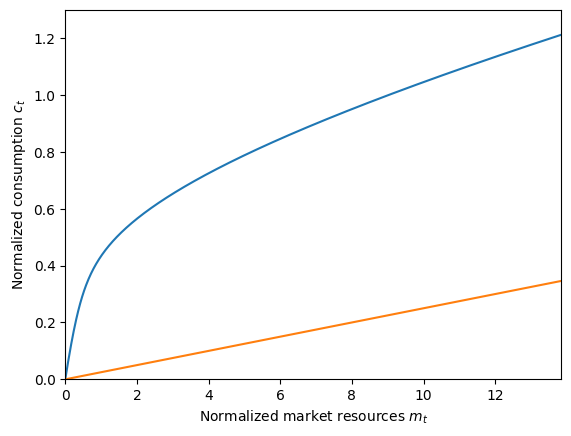

In [7]:
plt.ylim(0.0, 1.3)
plt.xlabel("Normalized market resources $m_t$")
plt.ylabel(r"Normalized consumption $c_t$")
plot_funcs(MarkovType.cFunc[0], 0, m_upper)

It *looks* the same, but let's plot the difference between employed consumption functions just to be sure.

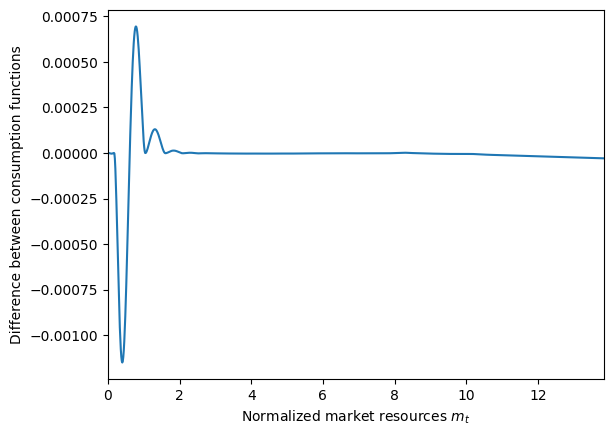

In [8]:
diffFunc = lambda m: ExampleType.solution[0].cFunc(m) - MarkovType.cFunc[0][0](m)
plt.xlabel("Normalized market resources $m_t$")
plt.ylabel(r"Difference between consumption functions")
plot_funcs(diffFunc, 0, m_upper)

That's a pretty tight match!